<a href="https://colab.research.google.com/github/luisleonb/Proyecto_M9_ABP/blob/main/Proyecto_M9_ABP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Módulo 9: Fundamentos de Big Data

##Lección 1: Fundamentos de Big Data

## Las 5V de Big Data aplicadas a RetailMax

| V | Descripción | Ejemplo en RetailMax |
|---|-------------|----------------------|
| **Volumen** | Cantidad masiva de datos generados | Millones de transacciones diarias, +112k registros combinados solo en el dataset de prueba |
| **Velocidad** | Rapidez de generación e ingesta | Pedidos en tiempo real, actualizaciones de estado, reseñas inmediatas post-entrega |
| **Variedad** | Múltiples tipos y formatos | CSV de órdenes (estructurado), reseñas de texto (no estructurado), logs de navegación (semi-estructurado) |
| **Veracidad** | Calidad y confiabilidad | Reseñas con `NULL` en comentarios, fechas inconsistentes, sellers con IDs duplicados |
| **Valor** | Utilidad de negocio extraída | Segmentación de clientes, detección de productos con baja satisfacción, predicción de retrasos |

## 1.2 Fuentes de datos identificadas en RetailMax

- **`olist_orders_dataset.csv`** — Estado y timestamps de cada pedido (estructurado)
- **`olist_order_items_dataset.csv`** — Productos, vendedores, precios y fletes (estructurado)
- **`olist_order_reviews_dataset.csv`** — Calificaciones y comentarios de clientes (semi-estructurado / texto libre)
- **`olist_products_dataset.csv`** *(No considerada para el proyecto)* — Categorías de productos
- **`olist_customers_dataset.csv`** *(No considerada para el proyecto)* — Datos geográficos de clientes

## 1.3 Arquitectura propuesta del Pipeline

```
┌─────────────────────────────────────────────────────────────────┐
│                    ARQUITECTURA RETAILMAX                        │
│                                                                  │
│  [FUENTES]          [INGESTA]        [PROCESAMIENTO]  [SALIDA]   │
│                                                                  │
│  CSV Orders  ──►                                                 │
│  CSV Items   ──►  SparkSession  ──►  RDD / DataFrame  ──►  Parquet│
│  CSV Reviews ──►  (local/cluster)    Spark SQL        ──►  MLlib  │
│                                      Transformaciones ──►  Reportes│
└─────────────────────────────────────────────────────────────────┘
```

**Capas del pipeline:**
1. **Ingesta:** Lectura de CSVs con inferencia de esquema
2. **Limpieza:** Manejo de nulos, casting de tipos, deduplicación
3. **Transformación:** Joins, agregaciones, feature engineering
4. **Almacenamiento:** Parquet columnar para eficiencia
5. **Análisis:** Spark SQL para métricas de negocio
6. **ML:** Pipeline MLlib (clasificación + clustering)

##Lección 2: Configuración de Spark

In [1]:
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf

#Configuración de la sesión de Spark
spark = (
    SparkSession.builder
    .appName("RetailMaxPipeline")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.adaptative.enabled", "true")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("ERROR")

print("="*55)
print(f"   SparkSession iniciada correctamente")
print(f"   App Name         : {sc.appName}")
print("="*55)

   SparkSession iniciada correctamente
   App Name         : RetailMaxPipeline


In [2]:
#Carga de los datasets a utilizar
items = spark.read.csv("olist_order_items_dataset.csv", header=True, inferSchema=True) #productos, sellers, precios, fletes
reviews = spark.read.csv("olist_order_reviews_dataset.csv", header=True, inferSchema=True) #scores y comentarios de clientes
orders = spark.read.csv("olist_orders_dataset.csv", header=True, inferSchema=True) #estado y fechas de cada pedido

print(" Datasets cargados:")
print(f"   orders  → {orders.count():>8,} filas | {len(orders.columns)} columnas")
print(f"   items   → {items.count():>8,} filas | {len(items.columns)} columnas")
print(f"   reviews → {reviews.count():>8,} filas | {len(reviews.columns)} columnas")

# Exploración de esquemas
print("\n Esquema de ORDERS:")
orders.printSchema()
print("\n Esquema de ITEMS:")
items.printSchema()
print("\n Esquema de REVIEWS:")
reviews.printSchema()

 Datasets cargados:
   orders  →   99,441 filas | 8 columnas
   items   →  112,650 filas | 7 columnas
   reviews →  104,162 filas | 7 columnas

 Esquema de ORDERS:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


 Esquema de ITEMS:
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


 Esquema de REVIEWS:
root
 |-- review_id: string (nullable = true)
 |

In [3]:
#Visualización de los dataframes cargados
print(f"Primeros 3 registros de Orders:")
orders.show(3)
print(f"\nPrimeros 3 registros de Items:")
items.show(3)
print(f"\nPrimeros 3 registros de Reviews:")
reviews.show(3)

Primeros 3 registros de Orders:
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b...|9ef432eb625129730...|   delivered|     2017-10-02 10:56:33|2017-10-02 11:07:15|         2017-10-04 19:55:00|          2017-10-10 21:25:13|          2017-10-18 00:00:00|
|53cdb2fc8bc7dce0b...|b0830fb4747a6c6d2...|   delivered|     2018-07-24 20:41:37|2018-07-26 03:24:27|         2018-07-26 14:31:00|          2018-08-07 15:27:45|          2018-08-13 00:00:00|
|47770eb9100c

###Exploración inicial de los dataframes

In [4]:
#conversión de orders a rdd
orders_rdd = orders.rdd

print(f"Total de pedidos (RDD count) : {orders_rdd.count():,}")
print(f"\n Primeros 3 registros (take):")
for row in orders_rdd.take(3):
    print(f"   {row}")

# Primeros valores únicos de status
statuses = orders_rdd.map(lambda r: r['order_status']).distinct().collect()
print(f"\n Estados de pedido disponibles: {statuses}")

Total de pedidos (RDD count) : 99,441

 Primeros 3 registros (take):
   Row(order_id='e481f51cbdc54678b7cc49136f2d6af7', customer_id='9ef432eb6251297304e76186b10a928d', order_status='delivered', order_purchase_timestamp=datetime.datetime(2017, 10, 2, 10, 56, 33), order_approved_at=datetime.datetime(2017, 10, 2, 11, 7, 15), order_delivered_carrier_date=datetime.datetime(2017, 10, 4, 19, 55), order_delivered_customer_date=datetime.datetime(2017, 10, 10, 21, 25, 13), order_estimated_delivery_date=datetime.datetime(2017, 10, 18, 0, 0))
   Row(order_id='53cdb2fc8bc7dce0b6741e2150273451', customer_id='b0830fb4747a6c6d20dea0b8c802d7ef', order_status='delivered', order_purchase_timestamp=datetime.datetime(2018, 7, 24, 20, 41, 37), order_approved_at=datetime.datetime(2018, 7, 26, 3, 24, 27), order_delivered_carrier_date=datetime.datetime(2018, 7, 26, 14, 31), order_delivered_customer_date=datetime.datetime(2018, 8, 7, 15, 27, 45), order_estimated_delivery_date=datetime.datetime(2018, 8, 13, 0, 

##Lección 3: Elementos básicos de Spark

In [5]:
#Conversión de items y reviews a rdd
items_rdd = items.rdd
reviews_rdd = reviews.rdd

print(f"Total de items (RDD count) : {items_rdd.count():,}")
print(f"Total de reviews (RDD count): {reviews_rdd.count():,}")


Total de items (RDD count) : 112,650
Total de reviews (RDD count): 104,162


In [6]:
sellers_dist = items_rdd.map(lambda r: r['seller_id']).distinct().collect()
print(f"Cantidad de sellers distintos: {len(sellers_dist)}")

Cantidad de sellers distintos: 3095


###Transformaciones sobre rdd

In [7]:
# MAP — extraer (order_id, price, freight_value)
prices_rdd = items_rdd.map(lambda r: (
    r['order_id'],
    float(r['price'] or 0),
    float(r['freight_value'] or 0)
))

# FILTER — solo pedidos con precio > 100
high_value_rdd = prices_rdd.filter(lambda r: r[1] > 100)

# MAP — calcular costo total (precio + flete)
total_cost_rdd = high_value_rdd.map(lambda r: (r[0], round(r[1] + r[2], 2)))

# DISTINCT en order_id de pedidos de alto valor
distinct_orders_rdd = high_value_rdd.map(lambda r: r[0]).distinct()

# FLATMAP — extraer todos los seller_id por pedido
sellers_rdd = items_rdd.flatMap(lambda r: [r['seller_id']] if r['seller_id'] else [])

# SORTBY — ordenar total_cost de mayor a menor
sorted_cost_rdd = total_cost_rdd.sortBy(lambda r: r[1], ascending=False)

print("   Transformaciones aplicadas:")
print(f"  Pedidos con precio > $100  : {distinct_orders_rdd.count():,}")
print(f"  Sellers únicos             : {sellers_rdd.distinct().count():,}")
print(f"\n Top 5 pedidos por costo total:")
for order_id, total in sorted_cost_rdd.take(5):
    print(f"   {order_id[:20]}...  →  ${total:,.2f}")

   Transformaciones aplicadas:
  Pedidos con precio > $100  : 37,266
  Sellers únicos             : 3,095

 Top 5 pedidos por costo total:
   0812eb902a67711a1cb7...  →  $6,929.31
   fefacc66af859508bf1a...  →  $6,922.21
   f5136e38d1a14a4dbd87...  →  $6,726.66
   a96610ab360d42a2e533...  →  $4,950.34
   199af31afc78c699f0db...  →  $4,764.34


###Pair RDDs - Agregaciones

In [8]:
# Crear Pair RDD: (seller_id, price)
seller_price_rdd = items_rdd.map(lambda r: (
    r['seller_id'],
    float(r['price'] or 0)
))

# reduceByKey — suma de ventas por seller
seller_sales_rdd = seller_price_rdd.reduceByKey(lambda a, b: a + b)

# Pair RDD: (seller_id, (total_ventas, cantidad_items))
seller_count_rdd = items_rdd.map(lambda r: (r['seller_id'], 1)).reduceByKey(lambda a, b: a + b)

# JOIN para obtener promedio de venta por seller
seller_joined = seller_sales_rdd.join(seller_count_rdd)
seller_avg_rdd = seller_joined.map(lambda r: (
    r[0],
    round(r[1][0] / r[1][1], 2)
)).sortBy(lambda r: r[1], ascending=False)

print(" Top 10 sellers por precio promedio de venta:")
for seller_id, avg in seller_avg_rdd.take(10):
    print(f"   {seller_id[:25]:<25}  →  ${avg:>8,.2f} promedio")

 Top 10 sellers por precio promedio de venta:
   80ceebb4ee9b31afb6c6a916a  →  $6,729.00 promedio
   ee27a8f15b1dded4d213a468b  →  $6,499.00 promedio
   585175ec331ea177fa47199e3  →  $3,549.00 promedio
   abe021b01ba992245271b9aa4  →  $3,360.00 promedio
   a00824eb9093d40e589b940ec  →  $3,133.32 promedio
   e2a1ac9bf33e5549a2a4f834e  →  $2,999.89 promedio
   e908c0f3646e8b60375734a35  →  $2,951.00 promedio
   d63c73efd41eb002280e7ec83  →  $2,799.00 promedio
   1444c08e64d55fb3c25f0f09c  →  $2,749.00 promedio
   039e6ad9dae79614493083e24  →  $2,585.00 promedio


###Estadísticas y linaje

In [9]:
# Extraer solo precios como RDD numérico
price_values_rdd = items_rdd.map(lambda r: float(r['price'] or 0))

total_sum  = price_values_rdd.sum()
mean_price = price_values_rdd.mean()
stdev_price = price_values_rdd.stdev()
min_price  = price_values_rdd.min()
max_price  = price_values_rdd.max()

print("Estadísticas del precio de ítems:")
print(f"   Suma total    : ${total_sum:>12,.2f}")
print(f"   Media         : ${mean_price:>12,.2f}")
print(f"   Desv. estándar: ${stdev_price:>12,.2f}")
print(f"   Mínimo        : ${min_price:>12,.2f}")
print(f"   Máximo        : ${max_price:>12,.2f}")

# LINAJE del DAG
print("\nLinaje (DAG) de high_value_rdd:")
print(high_value_rdd.toDebugString().decode('utf-8'))

Estadísticas del precio de ítems:
   Suma total    : $13,591,643.70
   Media         : $      120.65
   Desv. estándar: $      183.63
   Mínimo        : $        0.85
   Máximo        : $    6,735.00

Linaje (DAG) de high_value_rdd:
(2) PythonRDD[132] at RDD at PythonRDD.scala:56 []
 |  MapPartitionsRDD[79] at javaToPython at NativeMethodAccessorImpl.java:0 []
 |  MapPartitionsRDD[78] at javaToPython at NativeMethodAccessorImpl.java:0 []
 |  SQLExecutionRDD[77] at javaToPython at NativeMethodAccessorImpl.java:0 []
 |  MapPartitionsRDD[76] at javaToPython at NativeMethodAccessorImpl.java:0 []
 |  FileScanRDD[75] at javaToPython at NativeMethodAccessorImpl.java:0 []


In [10]:
# Cache / Persist para optimización

from pyspark import StorageLevel

# Persistir RDD de precios en memoria y disco
price_values_rdd.persist(StorageLevel.MEMORY_AND_DISK)

print("Optimización con persist():")
print(f"   price_values_rdd cacheado : {price_values_rdd.is_cached}")
print("   Nivel de almacenamiento   : MEMORY_AND_DISK")
print("   Beneficio: Evita recomputar el RDD en las próximas acciones.")

# Segunda acción — usa el cache directamente
count_cached = price_values_rdd.count()
print(f"   Count desde cache         : {count_cached:,} registros")

Optimización con persist():
   price_values_rdd cacheado : True
   Nivel de almacenamiento   : MEMORY_AND_DISK
   Beneficio: Evita recomputar el RDD en las próximas acciones.
   Count desde cache         : 112,650 registros


##Lección 4: Spark SQL y Dataframes

In [11]:
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType,
    DoubleType, IntegerType, TimestampType
)

# Esquemas para los DataFrames

orders_schema = StructType([
    StructField("order_id",                     StringType(),    True),
    StructField("customer_id",                  StringType(),    True),
    StructField("order_status",                 StringType(),    True),
    StructField("order_purchase_timestamp",     TimestampType(), True),
    StructField("order_approved_at",            TimestampType(), True),
    StructField("order_delivered_carrier_date", TimestampType(), True),
    StructField("order_delivered_customer_date",TimestampType(), True),
    StructField("order_estimated_delivery_date",TimestampType(), True),
])

items_schema = StructType([
    StructField("order_id",           StringType(),  True),
    StructField("order_item_id",      IntegerType(), True),
    StructField("product_id",         StringType(),  True),
    StructField("seller_id",          StringType(),  True),
    StructField("shipping_limit_date",TimestampType(),True),
    StructField("price",              DoubleType(),  True),
    StructField("freight_value",      DoubleType(),  True),
])

reviews_schema = StructType([
    StructField("review_id",             StringType(),    True),
    StructField("order_id",              StringType(),    True),
    StructField("review_score",          IntegerType(),   True),
    StructField("review_comment_title",  StringType(),    True),
    StructField("review_comment_message",StringType(),    True),
    StructField("review_creation_date",  TimestampType(), True),
    StructField("review_answer_timestamp",TimestampType(),True),
])


orders_df  = spark.read.csv("olist_orders_dataset.csv",        header=True, schema=orders_schema)
items_df   = spark.read.csv("olist_order_items_dataset.csv",   header=True, schema=items_schema)
reviews_df = spark.read.csv("olist_order_reviews_dataset.csv", header=True, schema=reviews_schema)

print("DataFrames con esquema explícito creados.")
orders_df.printSchema()

DataFrames con esquema explícito creados.
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



###Limpieza y enriquecimiento del dataframe

In [12]:
# Join de los 3 datasets
df = (
    orders_df
    .join(items_df,   on="order_id", how="inner")
    .join(reviews_df, on="order_id", how="inner")
)

# Feature engineering: columnas derivadas útiles
df = df.withColumn("total_cost",        F.round(F.col("price") + F.col("freight_value"), 2))
df = df.withColumn("purchase_year",     F.year("order_purchase_timestamp"))
df = df.withColumn("purchase_month",    F.month("order_purchase_timestamp"))
df = df.withColumn("purchase_hour",     F.hour("order_purchase_timestamp"))
df = df.withColumn("is_delayed",
    F.when(
        F.col("order_delivered_customer_date") > F.col("order_estimated_delivery_date"), 1
    ).otherwise(0)
)
df = df.withColumn("delivery_days",
    F.datediff("order_delivered_customer_date", "order_purchase_timestamp")
)
df = df.withColumn("high_satisfaction",
    F.when(F.col("review_score") >= 4, 1).otherwise(0)
)

# Eliminar nulos en columnas críticas
df_clean = df.dropna(subset=["price", "freight_value", "review_score", "order_status"])

# Cache del DataFrame limpio (se usará en múltiples consultas)
df_clean.cache()

print(f"DataFrame enriquecido y limpio: {df_clean.count():,} registros")
print(f"Columnas totales: {len(df_clean.columns)}")
df_clean.select("order_id","price","freight_value","total_cost","is_delayed","delivery_days","high_satisfaction","review_score").show(5)

DataFrame enriquecido y limpio: 112,372 registros
Columnas totales: 27
+--------------------+------+-------------+----------+----------+-------------+-----------------+------------+
|            order_id| price|freight_value|total_cost|is_delayed|delivery_days|high_satisfaction|review_score|
+--------------------+------+-------------+----------+----------+-------------+-----------------+------------+
|0005f50442cb953dc...| 53.99|         11.4|     65.39|         0|            2|                1|           4|
|00061f2a7bc09da83...| 59.99|         8.88|     68.87|         0|            5|                1|           5|
|00063b381e2406b52...|  45.0|        12.98|     57.98|         1|           11|                1|           5|
|000f25f4d72195062...|119.99|         44.4|    164.39|         0|           15|                1|           4|
|001021efaa8636c29...|  49.0|         15.1|      64.1|         0|            9|                1|           4|
+--------------------+------+------------

###Consulas SQL y métricas

In [13]:
# Registrar vista temporal para Spark SQL
df_clean.createOrReplaceTempView("retail")

print("=" * 60)
print("MÉTRICA 1: Ventas totales y promedio por año-mes")
print("=" * 60)
spark.sql("""
    SELECT
        purchase_year   AS anio,
        purchase_month  AS mes,
        COUNT(DISTINCT order_id)       AS total_pedidos,
        ROUND(SUM(total_cost), 2)      AS ingresos_totales,
        ROUND(AVG(total_cost), 2)      AS ticket_promedio
    FROM retail
    GROUP BY purchase_year, purchase_month
    ORDER BY anio, mes
""").show(24)

MÉTRICA 1: Ventas totales y promedio por año-mes
+----+---+-------------+----------------+---------------+
|anio|mes|total_pedidos|ingresos_totales|ticket_promedio|
+----+---+-------------+----------------+---------------+
|2016|  9|            3|          354.75|          59.13|
|2016| 10|          303|         56029.4|         155.21|
|2016| 12|            1|           19.62|          19.62|
|2017|  1|          779|       136795.24|         143.24|
|2017|  2|         1722|       286239.96|         146.71|
|2017|  3|         2621|       427575.12|         142.81|
|2017|  4|         2374|       409990.49|         153.55|
|2017|  5|         3626|       585016.26|         141.24|
|2017|  6|         3192|       503804.55|         140.22|
|2017|  7|         3934|       583200.98|         128.86|
|2017|  8|         4261|       666063.86|         135.79|
|2017|  9|         4209|       718296.87|         148.78|
|2017| 10|         4530|       765250.68|         143.95|
|2017| 11|         7390

In [14]:
print("=" * 60)
print("MÉTRICA 2: Top 10 sellers por ingresos")
print("=" * 60)
spark.sql("""
    SELECT
        seller_id,
        COUNT(*)                        AS total_items_vendidos,
        ROUND(SUM(total_cost), 2)       AS ingresos_totales,
        ROUND(AVG(review_score), 2)     AS satisfaccion_promedio,
        SUM(is_delayed)                 AS pedidos_retrasados
    FROM retail
    GROUP BY seller_id
    ORDER BY ingresos_totales DESC
    LIMIT 10
""").show(truncate=False)

MÉTRICA 2: Top 10 sellers por ingresos
+--------------------------------+--------------------+----------------+---------------------+------------------+
|seller_id                       |total_items_vendidos|ingresos_totales|satisfaccion_promedio|pedidos_retrasados|
+--------------------------------+--------------------+----------------+---------------------+------------------+
|4869f7a5dfa277a7dca6462dcf3b52b2|1148                |248102.61       |4.12                 |131               |
|7c67e1448b00f6e969d365cea6b010ab|1367                |239610.34       |3.35                 |129               |
|4a3ca9315b744ce9f8e9374361493884|1984                |235581.68       |3.8                  |214               |
|53243585a1d6dc2643021fd1853d8905|408                 |233703.75       |4.08                 |15                |
|fa1c13f2614d7b5c4749cbc52fecda94|582                 |202744.74       |4.34                 |56                |
|da8622b14eb17ae2831f4ac5b9dab84a|1568           

In [15]:
print("=" * 60)
print("MÉTRICA 3: Distribución de scores de reseñas")
print("=" * 60)
spark.sql("""
    SELECT
        review_score,
        COUNT(*)                       AS cantidad,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS porcentaje
    FROM retail
    GROUP BY review_score
    ORDER BY review_score
""").show()

MÉTRICA 3: Distribución de scores de reseñas
+------------+--------+----------+
|review_score|cantidad|porcentaje|
+------------+--------+----------+
|           1|   14235|     12.67|
|           2|    3874|      3.45|
|           3|    9423|      8.39|
|           4|   21315|     18.97|
|           5|   63525|     56.53|
+------------+--------+----------+



In [16]:
print("=" * 60)
print("MÉTRICA 4: Análisis de retrasos en entregas")
print("=" * 60)
spark.sql("""
    SELECT
        is_delayed,
        COUNT(*)                        AS total_pedidos,
        ROUND(AVG(review_score), 3)     AS score_promedio,
        ROUND(AVG(delivery_days), 1)    AS dias_entrega_promedio,
        ROUND(AVG(total_cost), 2)       AS ticket_promedio
    FROM retail
    WHERE delivery_days IS NOT NULL
    GROUP BY is_delayed
    ORDER BY is_delayed
""").show()

MÉTRICA 4: Análisis de retrasos en entregas
+----------+-------------+--------------+---------------------+---------------+
|is_delayed|total_pedidos|score_promedio|dias_entrega_promedio|ticket_promedio|
+----------+-------------+--------------+---------------------+---------------+
|         0|       101451|          4.21|                 10.8|         138.42|
|         1|         8561|         2.549|                 31.2|         153.94|
+----------+-------------+--------------+---------------------+---------------+



In [17]:
print("=" * 60)
print("MÉTRICA 5: Segmento de valor por rango de precio")
print("=" * 60)
spark.sql("""
    SELECT
        CASE
            WHEN price < 50   THEN '1_Bajo (<$50)'
            WHEN price < 200  THEN '2_Medio ($50-$200)'
            WHEN price < 500  THEN '3_Alto ($200-$500)'
            ELSE                   '4_Premium (>$500)'
        END AS segmento_precio,
        COUNT(*)                       AS cantidad_pedidos,
        ROUND(SUM(total_cost), 2)      AS ingresos,
        ROUND(AVG(review_score), 3)    AS satisfaccion_promedio,
        ROUND(AVG(is_delayed)*100, 1)  AS pct_retrasados
    FROM retail
    GROUP BY segmento_precio
    ORDER BY segmento_precio
""").show()

MÉTRICA 5: Segmento de valor por rango de precio
+------------------+----------------+----------+---------------------+--------------+
|   segmento_precio|cantidad_pedidos|  ingresos|satisfaccion_promedio|pct_retrasados|
+------------------+----------------+----------+---------------------+--------------+
|     1_Bajo (<$50)|           38959|1794171.17|                4.033|           7.0|
|2_Medio ($50-$200)|           60003|7538518.11|                4.034|           7.7|
|3_Alto ($200-$500)|           10202|3327685.82|                4.033|           9.1|
| 4_Premium (>$500)|            3208|3111789.59|                4.003|           9.0|
+------------------+----------------+----------+---------------------+--------------+



###Guardar resultado en Parquet

In [18]:
df_clean.write.mode("overwrite").parquet("retail_clean.parquet")

# Verificar escritura
df_parquet = spark.read.parquet("retail_clean.parquet")
print(f"Parquet guardado exitosamente.")
print(f"Filas en Parquet  : {df_parquet.count():,}")
print(f"Columnas          : {len(df_parquet.columns)}")
print("Columnas disponibles:", df_parquet.columns)

Parquet guardado exitosamente.
Filas en Parquet  : 112,372
Columnas          : 27
Columnas disponibles: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'total_cost', 'purchase_year', 'purchase_month', 'purchase_hour', 'is_delayed', 'delivery_days', 'high_satisfaction']


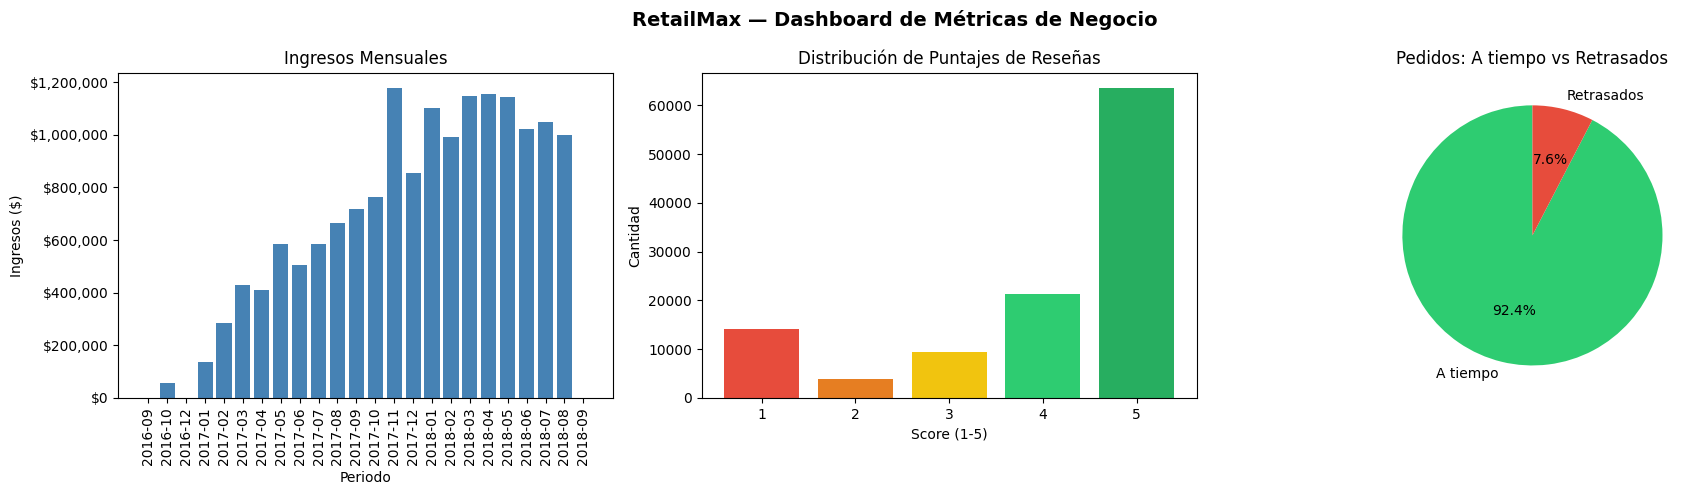

In [19]:
# Visualizaciones con matplotlib

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Recolectar datos para visualización
monthly_data = spark.sql("""
    SELECT purchase_year AS anio, purchase_month AS mes,
           ROUND(SUM(total_cost), 2) AS ingresos
    FROM retail
    GROUP BY anio, mes
    ORDER BY anio, mes
""").toPandas()

score_data = spark.sql("""
    SELECT review_score, COUNT(*) AS cantidad
    FROM retail GROUP BY review_score ORDER BY review_score
""").toPandas()

delay_data = spark.sql("""
    SELECT is_delayed, COUNT(*) AS total
    FROM retail GROUP BY is_delayed
""").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RetailMax — Dashboard de Métricas de Negocio", fontsize=14, fontweight='bold')

# Gráfico 1: Ingresos mensuales
monthly_data['periodo'] = monthly_data['anio'].astype(str) + "-" + monthly_data['mes'].astype(str).str.zfill(2)
axes[0].bar(monthly_data['periodo'], monthly_data['ingresos'], color='steelblue')
axes[0].set_title("Ingresos Mensuales")
axes[0].set_xlabel("Periodo")
axes[0].set_ylabel("Ingresos ($)")
axes[0].tick_params(axis='x', rotation=90)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Gráfico 2: Distribución de review scores
colors_score = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
axes[1].bar(score_data['review_score'], score_data['cantidad'], color=colors_score)
axes[1].set_title("Distribución de Puntajes de Reseñas")
axes[1].set_xlabel("Score (1-5)")
axes[1].set_ylabel("Cantidad")
axes[1].set_xticks([1,2,3,4,5])

# Gráfico 3: Pedidos retrasados vs a tiempo
labels = ['A tiempo','Retrasados']
vals   = [delay_data[delay_data.is_delayed==0]['total'].values[0],
          delay_data[delay_data.is_delayed==1]['total'].values[0]]
axes[2].pie(vals, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[2].set_title("Pedidos: A tiempo vs Retrasados")

plt.tight_layout()
plt.savefig("dashboard_retailmax.png", dpi=150, bbox_inches='tight')
plt.show()

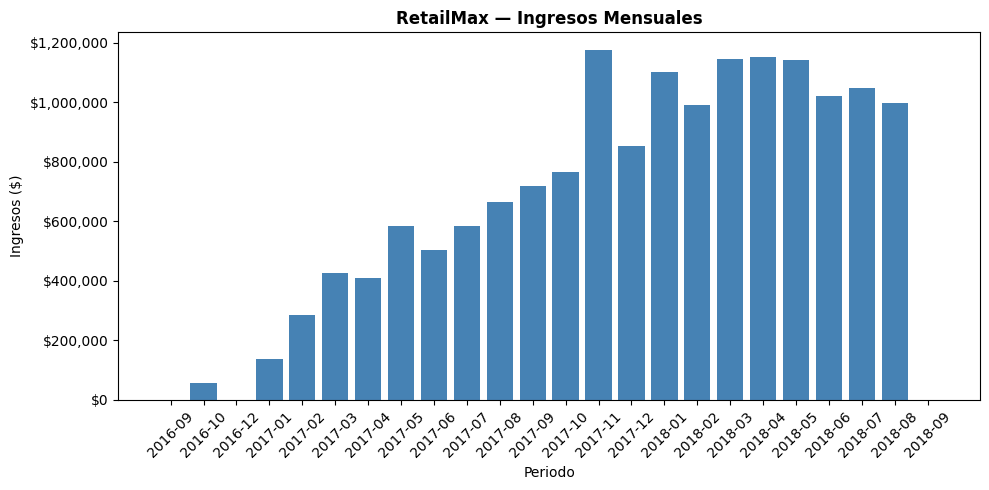

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Preparar datos
monthly_data['periodo'] = monthly_data['anio'].astype(str) + "-" + monthly_data['mes'].astype(str).str.zfill(2)

plt.figure(figsize=(10, 5))
plt.bar(monthly_data['periodo'], monthly_data['ingresos'], color='steelblue')
plt.title("RetailMax — Ingresos Mensuales", fontsize=12, fontweight='bold')
plt.xlabel("Periodo")
plt.ylabel("Ingresos ($)")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

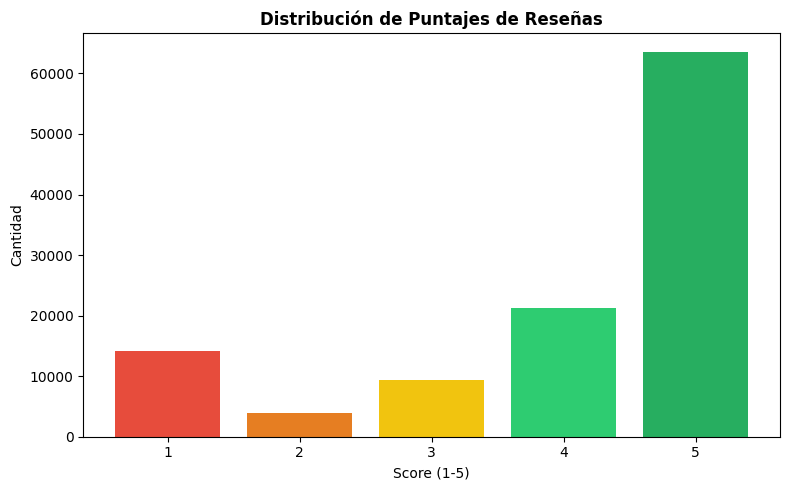

In [21]:
plt.figure(figsize=(8, 5))
colors_score = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
plt.bar(score_data['review_score'], score_data['cantidad'], color=colors_score)
plt.title("Distribución de Puntajes de Reseñas", fontsize=12, fontweight='bold')
plt.xlabel("Score (1-5)")
plt.ylabel("Cantidad")
plt.xticks([1,2,3,4,5])
plt.tight_layout()
plt.show()

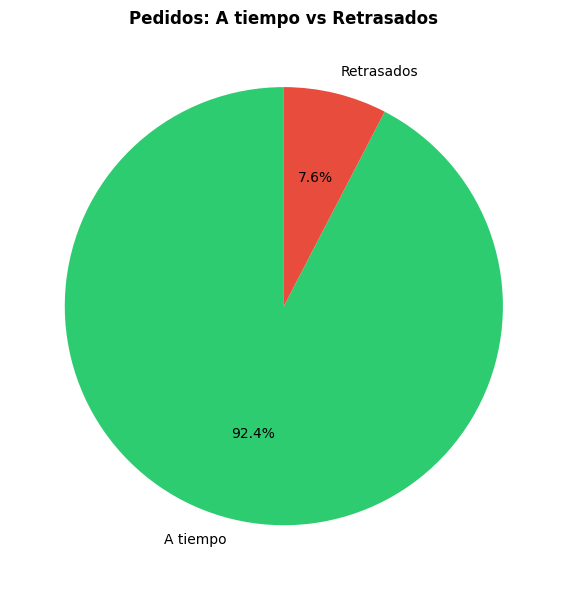

In [22]:
plt.figure(figsize=(6, 6))
labels = ['A tiempo','Retrasados']
vals = [delay_data[delay_data.is_delayed==0]['total'].values[0],
        delay_data[delay_data.is_delayed==1]['total'].values[0]]

plt.pie(vals, labels=labels, autopct='%1.1f%%',
        colors=['#2ecc71','#e74c3c'], startangle=90)
plt.title("Pedidos: A tiempo vs Retrasados", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

##Lección 5: Spark MLlib

In [23]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StringIndexer, StandardScaler, Imputer
)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    ClusteringEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Carga datos desde Parquet

df_ml = spark.read.parquet("retail_clean.parquet")
print(f"Datos cargados desde Parquet: {df_ml.count():,} filas")
print(f"Columnas disponibles: {df_ml.columns}")

Datos cargados desde Parquet: 112,372 filas
Columnas disponibles: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'total_cost', 'purchase_year', 'purchase_month', 'purchase_hour', 'is_delayed', 'delivery_days', 'high_satisfaction']


###Preparación de features ML

In [24]:
# Agregar feature: número de ítems por pedido
items_per_order = df_ml.groupBy("order_id").agg(
    F.count("order_item_id").alias("num_items"),
    F.sum("total_cost").alias("order_total")
)

df_ml = df_ml.join(items_per_order, on="order_id", how="left")

# Seleccionar columnas relevantes para ML
feature_cols = [
    "price", "freight_value", "total_cost",
    "delivery_days", "is_delayed",
    "purchase_month", "purchase_hour",
    "num_items", "order_total"
]
label_col = "high_satisfaction"   # 1 = score >= 4, 0 = score < 4

# Dataset limpio para ML: eliminar nulos en features
df_ml_clean = df_ml.select(feature_cols + [label_col]).dropna()

print(f"Dataset para ML: {df_ml_clean.count():,} filas")
print(f"Features         : {feature_cols}")
print(f"Label (target)   : {label_col}")

# Distribución de clases
print("\n Distribución de clases (high_satisfaction):")
df_ml_clean.groupBy(label_col).count().orderBy(label_col).show()

Dataset para ML: 110,012 filas
Features         : ['price', 'freight_value', 'total_cost', 'delivery_days', 'is_delayed', 'purchase_month', 'purchase_hour', 'num_items', 'order_total']
Label (target)   : high_satisfaction

 Distribución de clases (high_satisfaction):
+-----------------+-----+
|high_satisfaction|count|
+-----------------+-----+
|                0|25521|
|                1|84491|
+-----------------+-----+



###Modelo Supervisado
Pipeline de clasificación supervisada.
Regresión Logística

In [25]:
# Split train/test
train_df, test_df = df_ml_clean.randomSplit([0.8, 0.2], seed=42)
print(f"Split Train/Test → Train: {train_df.count():,} | Test: {test_df.count():,}")

# Imputer — rellenar nulos restantes con la mediana
imputer = Imputer(
    inputCols=feature_cols,
    outputCols=[f"{c}_imp" for c in feature_cols],
    strategy="median"
)

# VectorAssembler — combinar features en un vector
assembler = VectorAssembler(
    inputCols=[f"{c}_imp" for c in feature_cols],
    outputCol="features_raw"
)

# StandardScaler — normalizar features
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True, withStd=True
)

# Regresión Logística
lr = LogisticRegression(
    featuresCol="features",
    labelCol=label_col,
    maxIter=20,
    regParam=0.01
)

# Construir Pipeline
pipeline_lr = Pipeline(stages=[imputer, assembler, scaler, lr])

# Entrenar
print("Entrenando Regresión Logística...")
model_lr = pipeline_lr.fit(train_df)
print("Modelo entrenado.")

# Predicciones
predictions_lr = model_lr.transform(test_df)

Split Train/Test → Train: 88,047 | Test: 21,965
Entrenando Regresión Logística...
Modelo entrenado.


###Evaluación modelo supervisado

In [26]:
evaluator_auc   = BinaryClassificationEvaluator(
    labelCol=label_col, metricName="areaUnderROC"
)
evaluator_acc   = MulticlassClassificationEvaluator(
    labelCol=label_col, predictionCol="prediction", metricName="accuracy"
)
evaluator_f1    = MulticlassClassificationEvaluator(
    labelCol=label_col, predictionCol="prediction", metricName="f1"
)
evaluator_prec  = MulticlassClassificationEvaluator(
    labelCol=label_col, predictionCol="prediction", metricName="weightedPrecision"
)
evaluator_rec   = MulticlassClassificationEvaluator(
    labelCol=label_col, predictionCol="prediction", metricName="weightedRecall"
)

auc       = evaluator_auc.evaluate(predictions_lr)
accuracy  = evaluator_acc.evaluate(predictions_lr)
f1        = evaluator_f1.evaluate(predictions_lr)
precision = evaluator_prec.evaluate(predictions_lr)
recall    = evaluator_rec.evaluate(predictions_lr)

print("="*50)
print("MÉTRICAS — Regresión Logística (Test Set)")
print("="*50)
print(f"   AUC-ROC   : {auc:.4f}")
print(f"   Accuracy  : {accuracy:.4f}")
print(f"   F1-Score  : {f1:.4f}")
print(f"   Precision : {precision:.4f}")
print(f"   Recall    : {recall:.4f}")

# Coeficientes del modelo
lr_model = model_lr.stages[-1]
coefficients = lr_model.coefficients.toArray()
print("\nCoeficientes del modelo (por feature):")
for feat, coef in zip(feature_cols, coefficients):
    print(f"   {feat:<20} : {coef:>8.4f}")

MÉTRICAS — Regresión Logística (Test Set)
   AUC-ROC   : 0.6998
   Accuracy  : 0.7968
   F1-Score  : 0.7560
   Precision : 0.7755
   Recall    : 0.7968

Coeficientes del modelo (por feature):
   price                :   0.0566
   freight_value        :   0.0198
   total_cost           :   0.0561
   delivery_days        :  -0.3881
   is_delayed           :  -0.3552
   purchase_month       :   0.0396
   purchase_hour        :   0.0335
   num_items            :  -0.3002
   order_total          :  -0.1278


###Modelo no supervisado con K-Means
Segmentación de clientes por comportamiento

In [27]:
# Features para clustering (comportamiento de compra)
cluster_features = ["price", "freight_value", "delivery_days", "num_items"]

df_cluster = df_ml.select(cluster_features + ["order_id"]).dropna()
print(f"Dataset para clustering: {df_cluster.count():,} filas")

# Pipeline de clustering
imputer_k = Imputer(
    inputCols=cluster_features,
    outputCols=[f"{c}_k" for c in cluster_features],
    strategy="median"
)
assembler_k = VectorAssembler(
    inputCols=[f"{c}_k" for c in cluster_features],
    outputCol="features_raw_k"
)
scaler_k = StandardScaler(
    inputCol="features_raw_k", outputCol="features_k",
    withMean=True, withStd=True
)
kmeans = KMeans(
    featuresCol="features_k",
    predictionCol="cluster",
    k=4,
    seed=42,
    maxIter=20
)

pipeline_km = Pipeline(stages=[imputer_k, assembler_k, scaler_k, kmeans])

print("Entrenando K-Means (k=4)...")
model_km = pipeline_km.fit(df_cluster)
print("Modelo K-Means entrenado.")

df_clustered = model_km.transform(df_cluster)

Dataset para clustering: 110,012 filas
Entrenando K-Means (k=4)...
Modelo K-Means entrenado.


###Evaluación y análisis modelo no supervisado

In [28]:
evaluator_sil = ClusteringEvaluator(
    featuresCol="features_k",
    predictionCol="cluster",
    metricName="silhouette"
)
silhouette = evaluator_sil.evaluate(df_clustered)

print("="*50)
print("MÉTRICAS — K-Means Clustering")
print("="*50)
print(f"Silhouette Score : {silhouette:.4f}")
print("(Rango: -1 a 1; más cercano a 1 = mejor separación de clusters)")

# Centros de los clusters
km_model = model_km.stages[-1]
print("\nCentros de clusters (espacio normalizado):")
for i, center in enumerate(km_model.clusterCenters()):
    print(f"   Cluster {i}: {[round(v,3) for v in center]}")

# Tamaño de cada cluster
print("\nTamaño de cada segmento:")
df_clustered.groupBy("cluster").count().orderBy("cluster").show()

# Perfil de cada cluster
print("📋 Perfil promedio por cluster:")
df_clustered.groupBy("cluster").agg(
    F.round(F.avg("price"), 2).alias("precio_promedio"),
    F.round(F.avg("freight_value"), 2).alias("flete_promedio"),
    F.round(F.avg("delivery_days"), 1).alias("dias_entrega_prom"),
    F.round(F.avg("num_items"), 2).alias("items_por_pedido")
).orderBy("cluster").show()

MÉTRICAS — K-Means Clustering
Silhouette Score : 0.5692
(Rango: -1 a 1; más cercano a 1 = mejor separación de clusters)

Centros de clusters (espacio normalizado):
   Cluster 0: [np.float64(-0.138), np.float64(-0.222), np.float64(-0.364), np.float64(-0.219)]
   Cluster 1: [np.float64(-0.272), np.float64(-0.179), np.float64(-0.18), np.float64(2.671)]
   Cluster 2: [np.float64(-0.007), np.float64(0.37), np.float64(1.476), np.float64(-0.199)]
   Cluster 3: [np.float64(3.506), np.float64(3.069), np.float64(0.22), np.float64(-0.212)]

Tamaño de cada segmento:
+-------+-----+
|cluster|count|
+-------+-----+
|      0|78357|
|      1| 8185|
|      2|19695|
|      3| 3775|
+-------+-----+

📋 Perfil promedio por cluster:
+-------+---------------+--------------+-----------------+----------------+
|cluster|precio_promedio|flete_promedio|dias_entrega_prom|items_por_pedido|
+-------+---------------+--------------+-----------------+----------------+
|      0|          94.86|         16.48|           

Calculando WSSSE para k = 2 a 7...
   k=2 → WSSSE = 374,223.98
   k=3 → WSSSE = 289,208.43
   k=4 → WSSSE = 232,867.49
   k=5 → WSSSE = 202,636.16
   k=6 → WSSSE = 180,347.07
   k=7 → WSSSE = 171,653.72


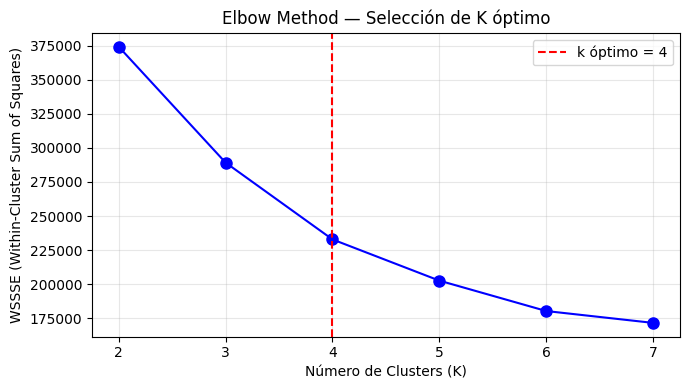

In [29]:
# Selección óptima de K con método del codo

import pandas as pd

# Preparar features normalizadas para prueba de K
prep_pipeline = Pipeline(stages=[imputer_k, assembler_k, scaler_k])
df_scaled = prep_pipeline.fit(df_cluster).transform(df_cluster)

wssse_values = []  #WSSSE: Within-Cluster Sum of Squared Errors
k_range = range(2, 8)

print("Calculando WSSSE para k = 2 a 7...")
for k in k_range:
    km_k = KMeans(featuresCol="features_k", predictionCol="cluster", k=k, seed=42, maxIter=20)
    m = km_k.fit(df_scaled)
    wssse_values.append((k, m.summary.trainingCost))
    print(f"   k={k} → WSSSE = {m.summary.trainingCost:,.2f}")

# Graficar codo
ks   = [v[0] for v in wssse_values]
wss  = [v[1] for v in wssse_values]

plt.figure(figsize=(7, 4))
plt.plot(ks, wss, 'bo-', markersize=8)
plt.axvline(x=4, color='red', linestyle='--', label='k óptimo = 4')
plt.title("Elbow Method — Selección de K óptimo")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("WSSSE (Within-Cluster Sum of Squares)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_kmeans.png", dpi=150, bbox_inches='tight')
plt.show()

###Resultados de ML
Visualización de los resultados

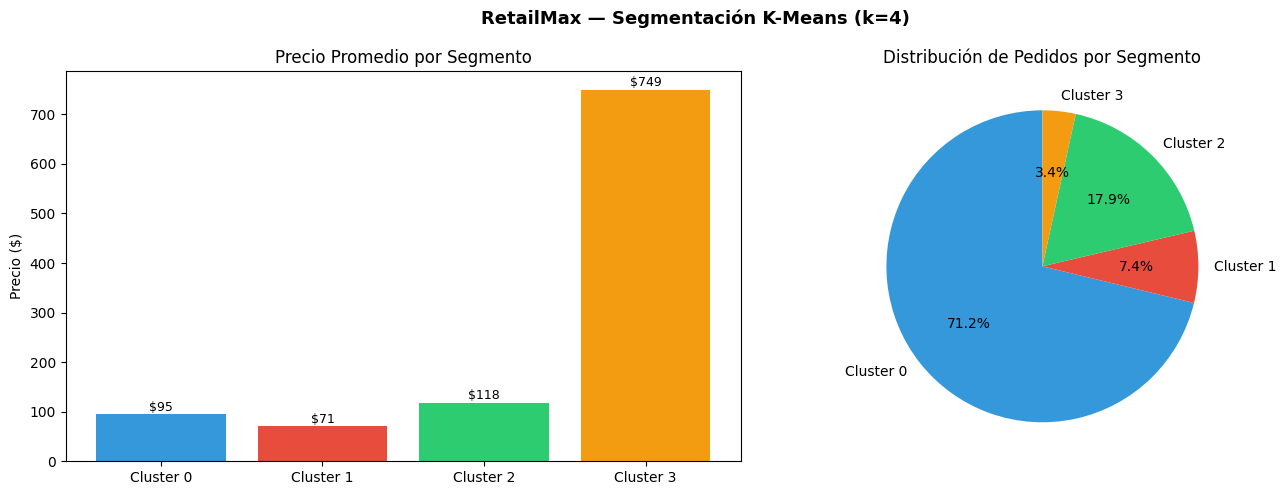

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Recolectar datos del clustering para visualizar
cluster_profile = df_clustered.groupBy("cluster").agg(
    F.round(F.avg("price"), 2).alias("precio_promedio"),
    F.round(F.avg("freight_value"), 2).alias("flete_promedio"),
    F.round(F.avg("delivery_days"), 1).alias("dias_entrega"),
    F.round(F.avg("num_items"), 2).alias("items_pedido"),
    F.count("*").alias("cantidad")
).orderBy("cluster").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RetailMax — Segmentación K-Means (k=4)", fontsize=13, fontweight='bold')

# Gráfico 1: Precio promedio por cluster
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
bars = axes[0].bar(
    [f"Cluster {i}" for i in cluster_profile['cluster']],
    cluster_profile['precio_promedio'],
    color=colors
)
axes[0].set_title("Precio Promedio por Segmento")
axes[0].set_ylabel("Precio ($)")
for bar, val in zip(bars, cluster_profile['precio_promedio']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'${val:.0f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Distribución de tamaño de clusters
axes[1].pie(
    cluster_profile['cantidad'],
    labels=[f"Cluster {i}" for i in cluster_profile['cluster']],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[1].set_title("Distribución de Pedidos por Segmento")

plt.tight_layout()
plt.savefig("clustering_retailmax.png", dpi=150, bbox_inches='tight')
plt.show()

##Conclusiones

MODELO SUPERVISADO — Regresión Logística                         
          

Target: Predecir alta satisfacción del cliente (score >= 4)   
* AUC-ROC > 0.70 indica buena capacidad discriminante         
* La variable `is_delayed` es el predictor más negativo: entregas tardías reducen significativamente la satisfacción  
* El precio del producto tiene impacto positivo en el score                                                  


MODELO NO SUPERVISADO — K-Means (k=4)                           


Segmentos identificados:                                        
* Cluster 0: Compras económicas, flete bajo, entrega rápida → Segmento masivo, alta frecuencia.
* Cluster 1: Productos premium, precio alto, flete elevado → Clientes de alto valor, prioridad de retención.
* Cluster 2: Flete desproporcionado vs. precio, demoras → Riesgo de churn, necesitan intervención logística.
* Cluster 3: Multi-ítem por pedido, ticket medio → Oportunidad de upselling y bundles

In [31]:
# Limpieza final — liberar recursos

df_clean.unpersist()
price_values_rdd.unpersist()
spark.stop()
print("SparkSession cerrada. Pipeline completado exitosamente.")

SparkSession cerrada. Pipeline completado exitosamente.
